# Cafe Sales Data Cleaning & Preprocessing

## Objective
Prepare the raw café sales dataset for analysis by:
- Standardizing invalid sentinel values
- Correcting data types
- Handling missing values using business logic first, then statistical fallbacks
- Removing duplicates
- Validating business rules (Quantity × Price Per Unit = Total Spent)
- Detecting and assessing outliers

## Step 1: Import Libraries and Load Dataset

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("cafe_sales.csv")
rows_original = len(df)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 10000 rows, 8 columns


### Understand the Dataset

In [5]:
df.head(15)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [6]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [8]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Unique values for each column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Transaction ID: 10000 unique values
Item: 10 unique values
Quantity: 7 unique values
Price Per Unit: 8 unique values
Total Spent: 19 unique values
Payment Method: 5 unique values
Location: 4 unique values
Transaction Date: 367 unique values


In [11]:
df.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [12]:
for col in df.columns:
    print(f"\n{'='*60}")
    print(col)
    print(df[col].value_counts(dropna=False))


Transaction ID
Transaction ID
TXN_1961373    1
TXN_4831525    1
TXN_1228927    1
TXN_6486912    1
TXN_3447069    1
              ..
TXN_5680238    1
TXN_7766134    1
TXN_2617257    1
TXN_8993132    1
TXN_6170729    1
Name: count, Length: 10000, dtype: int64

Item
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64

Quantity
Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
NaN         138
Name: count, dtype: int64

Price Per Unit
Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
NaN         179
UNKNOWN     164
Name: count, dtype: int64

Total Spent
Total Spent
6.0        979
12.0       939
3.0        930
4.0        923
20.0       746
15.0       734
8.0        677
10.0       52

## Step 2: Handle Invalid Values

`"UNKNOWN"` and `"ERROR"` are sentinel strings, not real data — they represent missing or corrupted entries.
Converting them to `NaN` lets pandas treat them consistently in all downstream steps.

In [13]:
# 2.1 Count invalid values before replacement
invalid_values = ["UNKNOWN", "ERROR"]

for col in df.columns:
    invalid_count = df[col].isin(invalid_values).sum()
    print(f"{col}: {invalid_count} invalid entries")

Transaction ID: 0 invalid entries
Item: 636 invalid entries
Quantity: 341 invalid entries
Price Per Unit: 354 invalid entries
Total Spent: 329 invalid entries
Payment Method: 599 invalid entries
Location: 696 invalid entries
Transaction Date: 301 invalid entries


In [37]:
# 2.2 Replace invalid values with NaN
df.replace(["UNKNOWN", "ERROR"], np.nan, inplace=True)

In [15]:
# Verify replacement
for col in df.columns:
    print(df[col].value_counts(dropna=False))
    print("=" * 60)

Transaction ID
TXN_1961373    1
TXN_4831525    1
TXN_1228927    1
TXN_6486912    1
TXN_3447069    1
              ..
TXN_5680238    1
TXN_7766134    1
TXN_2617257    1
TXN_8993132    1
TXN_6170729    1
Name: count, Length: 10000, dtype: int64
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
NaN          969
Name: count, dtype: int64
Quantity
5      2013
2      1974
4      1863
3      1849
1      1822
NaN     479
Name: count, dtype: int64
Price Per Unit
3.0    2429
4.0    2331
2.0    1227
5.0    1204
1.0    1143
1.5    1133
NaN     533
Name: count, dtype: int64
Total Spent
6.0     979
12.0    939
3.0     930
4.0     923
20.0    746
15.0    734
8.0     677
10.0    524
NaN     502
2.0     497
9.0     479
5.0     468
16.0    444
25.0    259
7.5     237
1.0     232
4.5     225
1.5     205
Name: count, dtype: int64
Payment Method
NaN               3178
Digital Wallet    2291
Credit Card       2273
Cas

## Step 3: Fix Data Types

In [16]:
# Convert numeric columns (coerce forces non-numeric to NaN)
numeric_cols = ["Quantity", "Price Per Unit", "Total Spent"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

### Transaction Date
Missing dates are **dropped** rather than mode-imputed.
Mode imputation (filling with the most frequent date) is statistically meaningless for time-series data
— it would artificially inflate transaction counts on a single day.

In [17]:
rows_before = len(df)
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# Drop rows where Transaction Date cannot be parsed
df.dropna(subset=["Transaction Date"], inplace=True)
print(f"Dropped {rows_before - len(df)} rows with unparseable Transaction Date")
print(f"Remaining rows: {len(df)}")

Dropped 460 rows with unparseable Transaction Date
Remaining rows: 9540


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9540 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9540 non-null   object        
 1   Item              8613 non-null   object        
 2   Quantity          9086 non-null   float64       
 3   Price Per Unit    9034 non-null   float64       
 4   Total Spent       9064 non-null   float64       
 5   Payment Method    6525 non-null   object        
 6   Location          5761 non-null   object        
 7   Transaction Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 670.8+ KB


## Step 4: Business Rule Validation

`Total Spent = Quantity × Price Per Unit`

We verify this holds before filling any missing values — if it's violated for complete rows, the data has integrity issues.

In [19]:
# Check consistency on rows where all three values are present
invalid_total = df[
    df["Quantity"].notna() &
    df["Price Per Unit"].notna() &
    df["Total Spent"].notna() &
    (round(df["Quantity"] * df["Price Per Unit"], 2) != round(df["Total Spent"], 2))
]

print(f"Rows violating business rule: {len(invalid_total)}")
invalid_total

Rows violating business rule: 0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


In [20]:
invalid_total.shape

(0, 8)

## Step 5: Handle Missing Values

### 5.1 Numeric columns — business logic first

We derive missing values from the relationship `Total Spent = Quantity × Price Per Unit`
before falling back to median imputation. This preserves real data wherever possible.

In [21]:
df.isnull().sum()

Transaction ID         0
Item                 927
Quantity             454
Price Per Unit       506
Total Spent          476
Payment Method      3015
Location            3779
Transaction Date       0
dtype: int64

In [22]:
# Derive missing Total Spent
mask = (
    df["Total Spent"].isna() &
    df["Quantity"].notna() &
    df["Price Per Unit"].notna()
)
df.loc[mask, "Total Spent"] = df.loc[mask, "Quantity"] * df.loc[mask, "Price Per Unit"]
print(f"Total Spent derived for {mask.sum()} rows")

Total Spent derived for 437 rows


In [23]:
# Derive missing Quantity
mask = (
    df["Quantity"].isna() &
    df["Total Spent"].notna() &
    df["Price Per Unit"].notna()
)
df.loc[mask, "Quantity"] = df.loc[mask, "Total Spent"] / df.loc[mask, "Price Per Unit"]
print(f"Quantity derived for {mask.sum()} rows")

Quantity derived for 418 rows


In [24]:
# Derive missing Price Per Unit
mask = (
    df["Price Per Unit"].isna() &
    df["Quantity"].notna() &
    df["Total Spent"].notna()
)
df.loc[mask, "Price Per Unit"] = df.loc[mask, "Total Spent"] / df.loc[mask, "Quantity"]
print(f"Price Per Unit derived for {mask.sum()} rows")

Price Per Unit derived for 471 rows


In [25]:
df.isnull().sum()

Transaction ID         0
Item                 927
Quantity              36
Price Per Unit        35
Total Spent           39
Payment Method      3015
Location            3779
Transaction Date       0
dtype: int64

### 5.2 Remaining numeric nulls — median fallback

In [26]:
# Median imputation for any remaining numeric nulls
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Price Per Unit"].median())

# Recalculate Total Spent for any rows still missing it
mask = df["Total Spent"].isna()
df.loc[mask, "Total Spent"] = (
    df.loc[mask, "Quantity"] * df.loc[mask, "Price Per Unit"]
)
print(f"Recalculated Total Spent for {mask.sum()} rows after median imputation")

Recalculated Total Spent for 39 rows after median imputation


In [27]:
df.isnull().sum()

Transaction ID         0
Item                 927
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      3015
Location            3779
Transaction Date       0
dtype: int64

### 5.3 Categorical columns — mode imputation

In [28]:
for col in df.select_dtypes(include="object").columns:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        print(f"  Filling '{col}' nulls with mode: '{mode_val}'")
        df[col].fillna(mode_val, inplace=True)

  Filling 'Item' nulls with mode: 'Juice'
  Filling 'Payment Method' nulls with mode: 'Digital Wallet'
  Filling 'Location' nulls with mode: 'Takeaway'


In [29]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [30]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


## Step 6: Standardize Categorical Columns

Strip leading/trailing whitespace from text columns — these are invisible in `value_counts()`
but cause silent mismatches in groupby operations and filters.

In [31]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

print("Whitespace stripped from all categorical columns.")
print(df.select_dtypes(include="object").nunique())

Whitespace stripped from all categorical columns.
Transaction ID    9540
Item                 8
Payment Method       3
Location             2
dtype: int64


## Step 7: Remove Duplicate Rows

In [32]:
rows_before_dedup = len(df)
print(f"Duplicate rows found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Removed {rows_before_dedup - len(df)} duplicates | Remaining: {len(df)} rows")

Duplicate rows found: 0
Removed 0 duplicates | Remaining: 9540 rows


## Step 8: Outlier Detection — Total Spent

We use **3×IQR** (extreme outlier threshold) rather than 1.5×IQR.
This is intentional: café transactions naturally vary in size (individual coffee vs. catering orders),
and 1.5×IQR would flag many valid high-value purchases.
After inspection, all detected extreme outliers were retained as genuine transactions.

In [33]:
Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outliers = df[
    (df["Total Spent"] < lower_bound) |
    (df["Total Spent"] > upper_bound)
]

print(f"Extreme outliers detected (3×IQR): {len(outliers)}")
print(f"  Lower bound: {lower_bound:.2f}")
print(f"  Upper bound: {upper_bound:.2f}")
outliers.sort_values("Total Spent", ascending=False).head(10)

Extreme outliers detected (3×IQR): 0
  Lower bound: -20.00
  Upper bound: 36.00


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


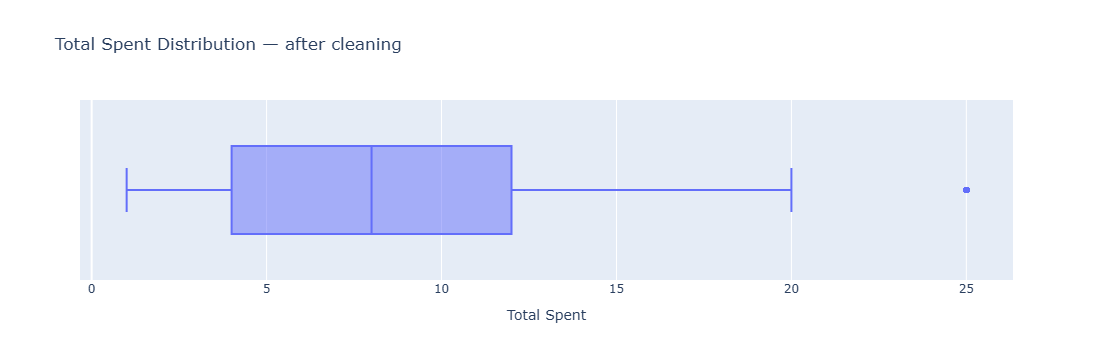

In [34]:
fig = px.box(df, x="Total Spent", title="Total Spent Distribution — after cleaning")
fig.show()

**Decision:** Outliers retained.
These represent valid high-value transactions (e.g. large group orders), not data entry errors.
Removing them would bias revenue analysis downward.

## Final Summary — Clean Dataset

In [35]:
print("=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)
print(f"Original rows   : {rows_original}")
print(f"Final rows      : {len(df)}")
print(f"Rows removed    : {rows_original - len(df)}")
print(f"Missing values  : {df.isnull().sum().sum()}")
print(f"Duplicates      : {df.duplicated().sum()}")
print()
print("--- Data Types ---")
print(df.dtypes)
print()
print("--- Numeric Summary ---")
df.describe()

FINAL DATASET SUMMARY
Original rows   : 10000
Final rows      : 9540
Rows removed    : 460
Missing values  : 0
Duplicates      : 0

--- Data Types ---
Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

--- Numeric Summary ---


,Quantity,Price Per Unit,Total Spent,Transaction Date
count,9540.000000,9540.000000,9540.000000,9540
mean,3.021908,2.949476,8.924109,2023-07-01 23:00:31.698113536
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-04-01 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-02 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-02 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.417191,1.276595,5.997956,NaN


In [36]:
df.sample(15)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
4826,TXN_7475500,Cookie,2.0,1.0,2.0,Cash,Takeaway,2023-11-22
7713,TXN_1665056,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-01-05
238,TXN_5526852,Sandwich,5.0,4.0,20.0,Digital Wallet,In-store,2023-09-28
9060,TXN_1899114,Tea,3.0,1.5,4.5,Digital Wallet,Takeaway,2023-04-05
5420,TXN_1707251,Sandwich,2.0,4.0,8.0,Digital Wallet,Takeaway,2023-10-06
5641,TXN_9447946,Smoothie,2.0,4.0,8.0,Credit Card,In-store,2023-10-21
4651,TXN_1817076,Juice,3.0,3.0,9.0,Cash,In-store,2023-05-31
167,TXN_4062737,Cake,3.0,3.0,9.0,Cash,In-store,2023-07-02
8696,TXN_4376376,Juice,3.0,5.0,15.0,Digital Wallet,Takeaway,2023-09-05
575,TXN_1109715,Cake,1.0,3.0,3.0,Digital Wallet,In-store,2023-07-15


## Conclusion

| Step | Action |
|------|--------|
| Invalid values | `"UNKNOWN"` / `"ERROR"` → NaN |
| Data types | Numeric columns coerced; Transaction Date parsed as datetime |
| Transaction Date nulls | Rows dropped (mode imputation is meaningless for dates) |
| Numeric nulls | Business logic (Quantity × Price) → median fallback |
| Categorical nulls | Mode imputation |
| Business rule | `Total Spent = Quantity × Price Per Unit` validated |
| Whitespace | Stripped from all categorical columns |
| Duplicates | Detected and removed (before/after count reported) |
| Outliers | Detected with 3×IQR; retained as valid high-value transactions |

The dataset is now ready for exploratory data analysis and feature engineering.
